# Dataset Exploration
In this notebook, we explore the FER-2013 dataset. We will check the class distribution and visualize some sample images.


In [5]:
import os
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
import numpy as np
from pathlib import Path

# Define paths
dataset_path = Path('../dataset')
train_path = dataset_path / 'train'
test_path = dataset_path / 'test'
vis_path = Path('../visualizations')
vis_path.mkdir(exist_ok=True)

## 1. Class Distribution Analysis
Let's count how many images belong to each emotion class in both the training and testing sets.


In [6]:
def get_class_counts(folder_path):
    counts = {}
    if not folder_path.exists():
        return counts
    for class_dir in os.listdir(folder_path):
        class_path = folder_path / class_dir
        if class_path.is_dir():
            counts[class_dir] = len(os.listdir(class_path))
    return counts

train_counts = get_class_counts(train_path)
test_counts = get_class_counts(test_path)

print("Training Set Counts:", train_counts)
print("Testing Set Counts:", test_counts)

Training Set Counts: {'angry': 3995, 'disgust': 436, 'fear': 4097, 'happy': 7215, 'neutral': 4965, 'sad': 4830, 'surprise': 3171}
Testing Set Counts: {'angry': 958, 'disgust': 111, 'fear': 1024, 'happy': 1774, 'neutral': 1233, 'sad': 1247, 'surprise': 831}


Let's plot the distribution to check for class imbalances.


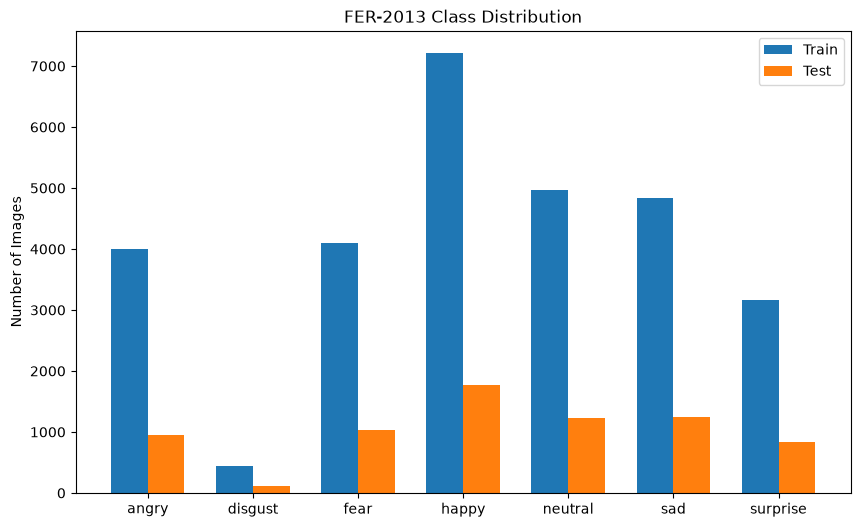

In [7]:
classes = list(train_counts.keys())
train_values = [train_counts[c] for c in classes]
test_values = [test_counts.get(c, 0) for c in classes]

x = np.arange(len(classes))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))
ax.bar(x - width/2, train_values, width, label='Train')
ax.bar(x + width/2, test_values, width, label='Test')

ax.set_ylabel('Number of Images')
ax.set_title('FER-2013 Class Distribution')
ax.set_xticks(x)
ax.set_xticklabels(classes)
ax.legend()

plt.savefig(vis_path / 'class_distribution.png')
plt.show()

## 2. Sample Image Visualization
Now, let's look at one sample image from each class to understand the data.


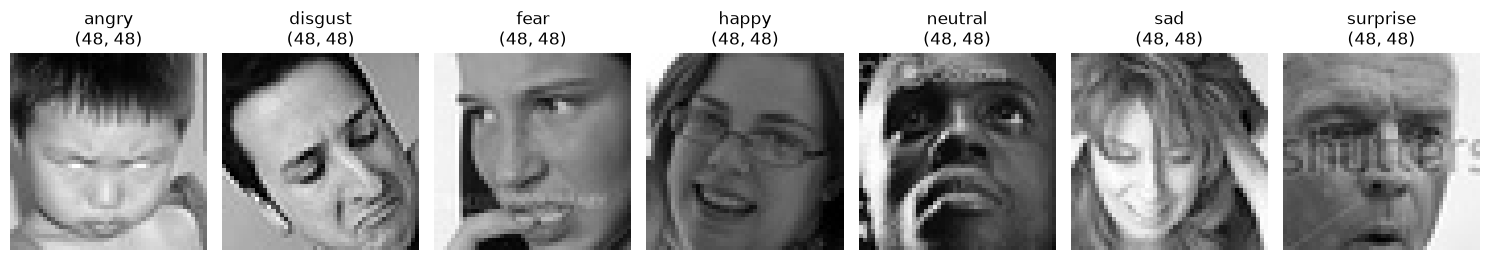

In [8]:
fig, axes = plt.subplots(1, len(classes), figsize=(15, 3))

for i, emotion in enumerate(classes):
    emotion_folder = train_path / emotion
    if emotion_folder.exists() and len(os.listdir(emotion_folder)) > 0:
        sample_img_name = os.listdir(emotion_folder)[0]
        sample_img_path = emotion_folder / sample_img_name
        
        img = cv2.imread(str(sample_img_path), cv2.IMREAD_GRAYSCALE)
        
        axes[i].imshow(img, cmap='gray')
        axes[i].set_title(f"{emotion}\n{img.shape}")
        axes[i].axis('off')

plt.tight_layout()
plt.savefig(vis_path / 'sample_images.png')
plt.show()